## 1. Kurulum ve Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

## 2. Veri Yükleme

In [2]:
df = yf.download('AMZN', start='2012-01-01', auto_adjust=True)
df = df.dropna()
print("Eksik değer sayısı:", df['Close'].isna().sum())
print(df.tail(3))
print(f"Toplam gün sayısı: {len(df)}")

[*********************100%***********************]  1 of 1 completed

Eksik değer sayısı: Ticker
AMZN    0
dtype: int64
Price            Close        High         Low        Open    Volume
Ticker            AMZN        AMZN        AMZN        AMZN      AMZN
Date                                                                
2026-08-12  267.279999  273.459991  267.100006  273.179993  29941100
2026-08-13  265.130005  269.579987  264.709991  267.239990  32170200
2026-08-14  262.649994  265.809998  262.420013  264.880005  27251700
Toplam gün sayısı: 3675


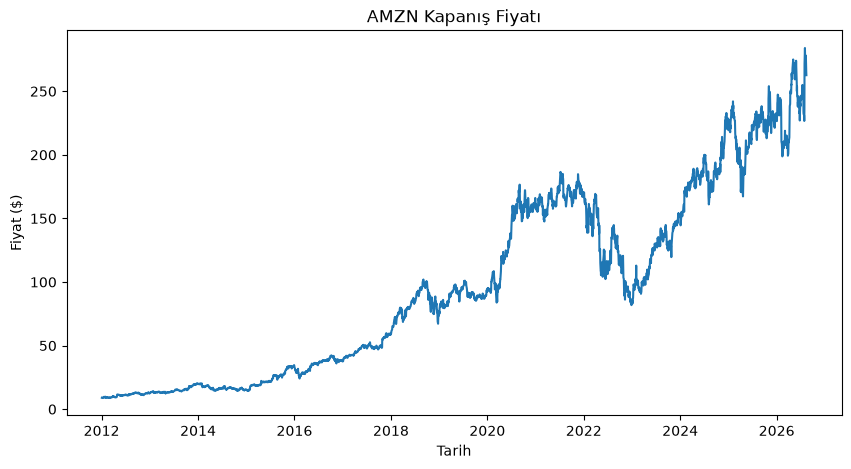

In [3]:
close_prices = df['Close']

plt.figure(figsize=(10, 5))
plt.plot(close_prices)
plt.title('AMZN Kapanış Fiyatı')
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.show()

## 3. Veri Ön İşleme

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
close_values = close_prices.values.reshape(-1, 1)
scaled_close = scaler.fit_transform(close_values)

print(scaled_close[:5])

[[-0.99887364]
 [-0.99942592]
 [-0.99938959]
 [-0.99757288]
 [-0.99904441]]


In [5]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_close, lookback)
print(X.shape, y.shape)

(3655, 20, 1) (3655, 1)


In [6]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(X_train.shape, X_test.shape)

(2924, 20, 1) (731, 20, 1)


In [7]:
X_train_t = torch.from_numpy(X_train).type(torch.Tensor)
X_test_t = torch.from_numpy(X_test).type(torch.Tensor)
y_train_t = torch.from_numpy(y_train).type(torch.Tensor)
y_test_t = torch.from_numpy(y_test).type(torch.Tensor)

print(X_train_t.shape, y_train_t.shape)

torch.Size([2924, 20, 1]) torch.Size([2924, 1])


## 4. Model Tanımları

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## 5. LSTM Eğitimi

In [9]:
torch.manual_seed(42)
model = LSTMModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 300      
train_losses = []

for epoch in range(num_epochs):
    model.train()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch % 30 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

print(f"Son loss: {train_losses[-1]:.6f}")

Epoch 0, Loss: 0.493367
Epoch 30, Loss: 0.005295
Epoch 60, Loss: 0.001046
Epoch 90, Loss: 0.000667
Epoch 120, Loss: 0.000556
Epoch 150, Loss: 0.000521
Epoch 180, Loss: 0.000499
Epoch 210, Loss: 0.000479
Epoch 240, Loss: 0.000461
Epoch 270, Loss: 0.000444
Son loss: 0.000429


## 6. GRU Modeli ve Eğitimi

In [10]:
class GRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        out, hn = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [11]:
import time

torch.manual_seed(42)
gru_model = GRUModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.01)

num_epochs = 100
gru_train_losses = []

start_time = time.time()
for epoch in range(num_epochs):
    gru_model.train()
    y_pred = gru_model(X_train_t)
    loss = criterion(y_pred, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    gru_train_losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

end_time = time.time()
print(f"\nGRU eğitim süresi: {end_time - start_time:.2f} saniye")

Epoch 0, Loss: 0.346619
Epoch 10, Loss: 0.027736
Epoch 20, Loss: 0.007034
Epoch 30, Loss: 0.001025
Epoch 40, Loss: 0.000414
Epoch 50, Loss: 0.000319
Epoch 60, Loss: 0.000273
Epoch 70, Loss: 0.000263
Epoch 80, Loss: 0.000254
Epoch 90, Loss: 0.000237

GRU eğitim süresi: 6.42 saniye


## 7. Değerlendirme ve Karşılaştırma

In [12]:
model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_test_pred = model(X_test_t)
    gru_test_pred = gru_model(X_test_t)

In [13]:
lstm_pred_real = scaler.inverse_transform(lstm_test_pred.numpy())
gru_pred_real = scaler.inverse_transform(gru_test_pred.numpy())
y_test_real = scaler.inverse_transform(y_test_t.numpy())

In [14]:
from sklearn.metrics import mean_squared_error

lstm_mse = mean_squared_error(y_test_real, lstm_pred_real)
lstm_rmse = np.sqrt(lstm_mse)

gru_mse = mean_squared_error(y_test_real, gru_pred_real)
gru_rmse = np.sqrt(gru_mse)

print(f"LSTM -> MSE: {lstm_mse:.2f}, RMSE: {lstm_rmse:.2f}")
print(f"GRU  -> MSE: {gru_mse:.2f}, RMSE: {gru_rmse:.2f}")

LSTM -> MSE: 165.72, RMSE: 12.87
GRU  -> MSE: 100.26, RMSE: 10.01


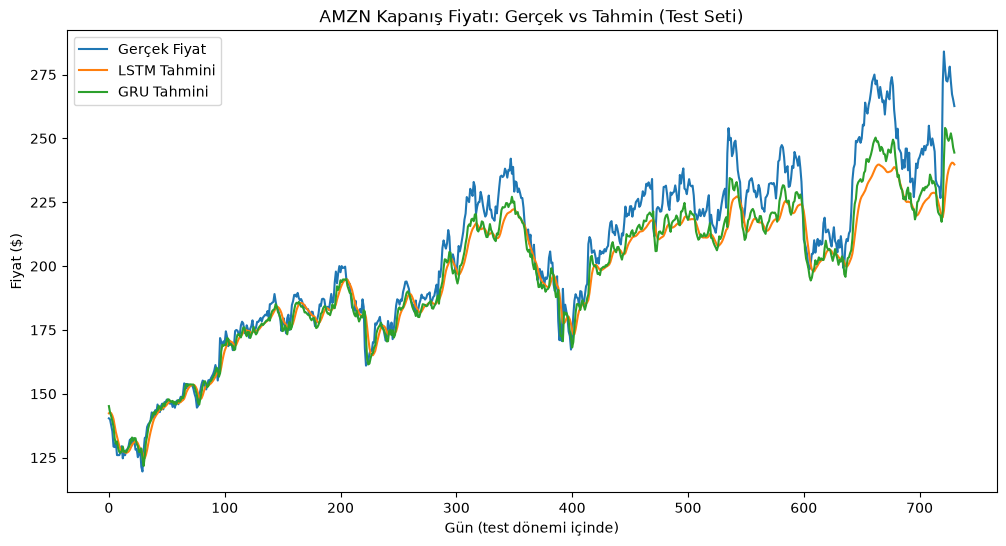

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Gerçek Fiyat')
plt.plot(lstm_pred_real, label='LSTM Tahmini')
plt.plot(gru_pred_real, label='GRU Tahmini')
plt.title('AMZN Kapanış Fiyatı: Gerçek vs Tahmin (Test Seti)')
plt.xlabel('Gün (test dönemi içinde)')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()